In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [5]:
df=pd.read_csv("diabetes.csv")

In [7]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2, random_state=42)
svm=SVC(C=1,random_state=42,kernel='rbf')
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
print( classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



Today, bots (scrapers, crawlers, and AI agents) roam the web freely, taking what they want. This solution flips the script: it creates a machine-readable gatekeeper that represents you.
How it works in 3 steps:
The Policy: You set your rules on a website (e.g., "AI can read my public posts but cannot train on my personal photos," or "No sales bots allowed").
The Handshake: When an AI agent tries to access your data or inbox, it hits your "Agent Firewall" first.
The Negotiation: Your firewall asks for the bot's credentials. If the bot is "verified ethical" and agrees to your terms, it gets a temporary "key" to enter. If not, it's blocked instantly.
Why it’s necessary:
It moves us from a "wild west" internet to a consent-based web, where humans—not algorithms—decide who gets to use their digital footprint.

In [ ]:
. The "LinkedIn" Scraper Case (Data Privacy)
The Scenario: A new AI startup wants to build a "Person-Search" tool. Their bots are crawling every profile to scrape names, job histories, and contact info without asking.
Without the Bouncer: The bot takes your data, sells it to recruiters, and you start getting spam calls.
With the Bouncer: The bot hits your profile. Your Agent Firewall interrupts: "Who are you? Do you have a 'Fair-Trade AI' certification?" The bot admits it's for-profit and non-transparent. Your Bouncer says: "Access Denied." Your data remains priva

The Scenario: You are a writer or coder with a personal blog. A massive LLM (like a future ChatGPT) wants to "read" your site to train its next model.
Without the Bouncer: They take your unique ideas and style for free, then charge others to use a tool that imitates you.
With the Bouncer: The LLM's crawler encounters your Bouncer. It sees your rule: "Training use allowed ONLY if a 'Source Citation' tag is hardcoded and I get a 0.001% royalty on generated outputs." The LLM must "sign" a digital contract before your website unlocks its content for the crawler.

In [30]:
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [31]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [32]:
df=df.dropna()
x=df.drop('depression_label',axis=1)
x=pd.get_dummies(x)
y=df['depression_label']
test=[0.05,0.1,0.15,0.2,0.25]
d={'model':[],'acc':[],'test_size':[]}
for i in test:
    x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=i, random_state=42)
    knn=KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,knn.predict(x_test)))
    d['model'].append('knn')
    d['test_size'].append(i)
    dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
    dt.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,dt.predict(x_test)))
    d['model'].append('dt')
    d['test_size'].append(i)
    rf=RandomForestClassifier(criterion='entropy',max_depth=4,random_state=42,n_estimators=100)
    rf.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,rf.predict(x_test)))
    d['model'].append('rf')
    d['test_size'].append(i)
    svm=SVC(C=1,random_state=42,kernel='rbf')
    svm.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,svm.predict(x_test)))
    d['model'].append('svm')
    d['test_size'].append(i)
df=pd.DataFrame(d)
df

,model,acc,test_size
0,knn,0.933333,0.05
1,dt,1.000000,0.05
2,rf,0.933333,0.05
3,svm,0.933333,0.05
4,knn,0.958333,0.10
5,dt,1.000000,0.10
6,rf,0.958333,0.10
7,svm,0.958333,0.10
8,knn,0.972222,0.15
9,dt,1.000000,0.15


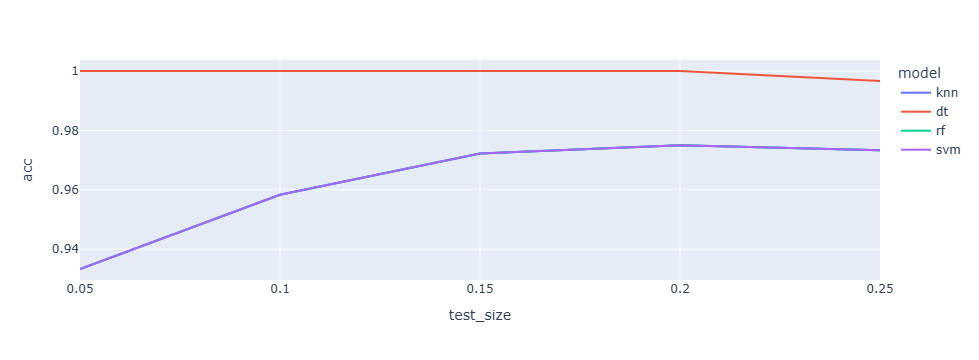

In [33]:
px.line(data_frame=df,x='test_size',y='acc',color='model')

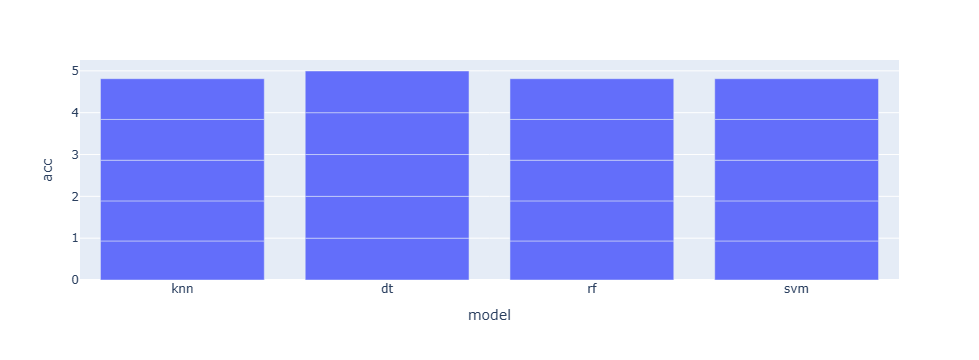

In [34]:
result=df.groupby('model')['acc'].max().reset_index()
px.bar(data_frame=df,x='model',y='acc')

In [43]:
df=pd.read_csv('created_house_price_prediction.csv')
df=df.dropna()

In [46]:
x=df.drop('Price',axis=1)
x=pd.get_dummies(x)
y=df['Price']
x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2, random_state=42)
r2=0
for i in range(1,9):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    lr=LinearRegression()
    lr.fit(x_train_poly,y_train)
    y_pred=lr.predict(x_test_poly)
    r2_s=r2_score(y_test,y_pred)
    if r2<r2_s:
        r2=r2_s
        deg=i
print('degree',deg,'>',r2)
    


degree 5 > 0.922891811658237


ValueError: x and y must have same first dimension, but have shapes (5,) and (0,)

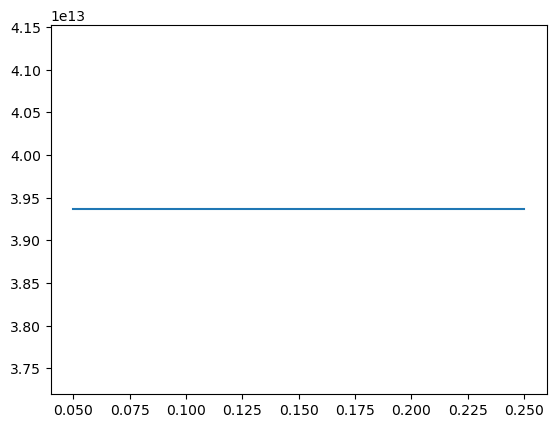

In [49]:
import matplotlib.pyplot as plt
mse_poly=[]
r2_poly=[]
mse=[]
r2=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2, random_state=42)
    poly=PolynomialFeatures(degree=5)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    lr=LinearRegression()
    lr.fit(x_train_poly,y_train)
    y_pred=lr.predict(x_test_poly)
    r2_poly.append(r2_score(y_test,y_pred))
    mse_poly.append(mean_sqaured_error(y_test,y_pred))
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_
    r2.append(r2_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))
plt.plot(test,mse)
plt.plot(test,mse_poly)
plt.show()
plt.plot(test,r2)
plt.plot(test,r2_poly)
plt.show()

In [40]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Garage', 'YearBuilt', 'Location',
       'Price'],
      dtype='object')